Year: The calendar year of the observation (from 1990 to 2010).

Lag1: Percentage return for the previous week (1-week lag).

Lag2: Percentage return for two weeks ago (2-week lag).

Lag3: Percentage return for three weeks ago (3-week lag).

Lag4: Percentage return for four weeks ago (4-week lag).

Lag5: Percentage return for five weeks ago (5-week lag).

Volume: The average daily number of shares traded (in billions) during that week.

Today: The weekly return for the current week (the one being predicted).

Direction: The market movement direction for the current week.

- "Up" if Today’s return > 0

- "Down" if Today’s return < 0

####13. This question should be answered using the Weekly data set, which is part of the ISLP package. This data is similar in nature to the Smarket data from this chapter's lab, except that it contains 1,089 weekly returns for 21 years, from the beginning of 1990 to the end of 2010.

####(a) Produce some numerical and graphical summaries of the Weekly data. Do there appear to be any patterns?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [ ]:
!pip install ISLP
from ISLP import load_data
weekly = load_data('Weekly')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=1db4cc053bd37626390d7ef0c0c94147179628485b4e91d4296201be63516157
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [ ]:
weekly.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


In [ ]:
print(weekly['Direction'].value_counts())
print(weekly.corr(numeric_only=True))

Direction
Up      605
Down    484
Name: count, dtype: int64
            Year      Lag1      Lag2      Lag3      Lag4      Lag5    Volume  \
Year    1.000000 -0.032289 -0.033390 -0.030006 -0.031128 -0.030519  0.841942   
Lag1   -0.032289  1.000000 -0.074853  0.058636 -0.071274 -0.008183 -0.064951   
Lag2   -0.033390 -0.074853  1.000000 -0.075721  0.058382 -0.072499 -0.085513   
Lag3   -0.030006  0.058636 -0.075721  1.000000 -0.075396  0.060657 -0.069288   
Lag4   -0.031128 -0.071274  0.058382 -0.075396  1.000000 -0.075675 -0.061075   
Lag5   -0.030519 -0.008183 -0.072499  0.060657 -0.075675  1.000000 -0.058517   
Volume  0.841942 -0.064951 -0.085513 -0.069288 -0.061075 -0.058517  1.000000   
Today  -0.032460 -0.075032  0.059167 -0.071244 -0.007826  0.011013 -0.033078   

           Today  
Year   -0.032460  
Lag1   -0.075032  
Lag2    0.059167  
Lag3   -0.071244  
Lag4   -0.007826  
Lag5    0.011013  
Volume -0.033078  
Today   1.000000  


- The response variable Direction shows: The market goes up slightly more than half of the time.

- Volume shows a strong positive correlation with Year (≈ 0.84), indicating that trading volume has generally increased over time.

- The lag variables (Lag1–Lag5) show weak correlations with Today, suggesting limited linear predictability from past weeks’ returns.

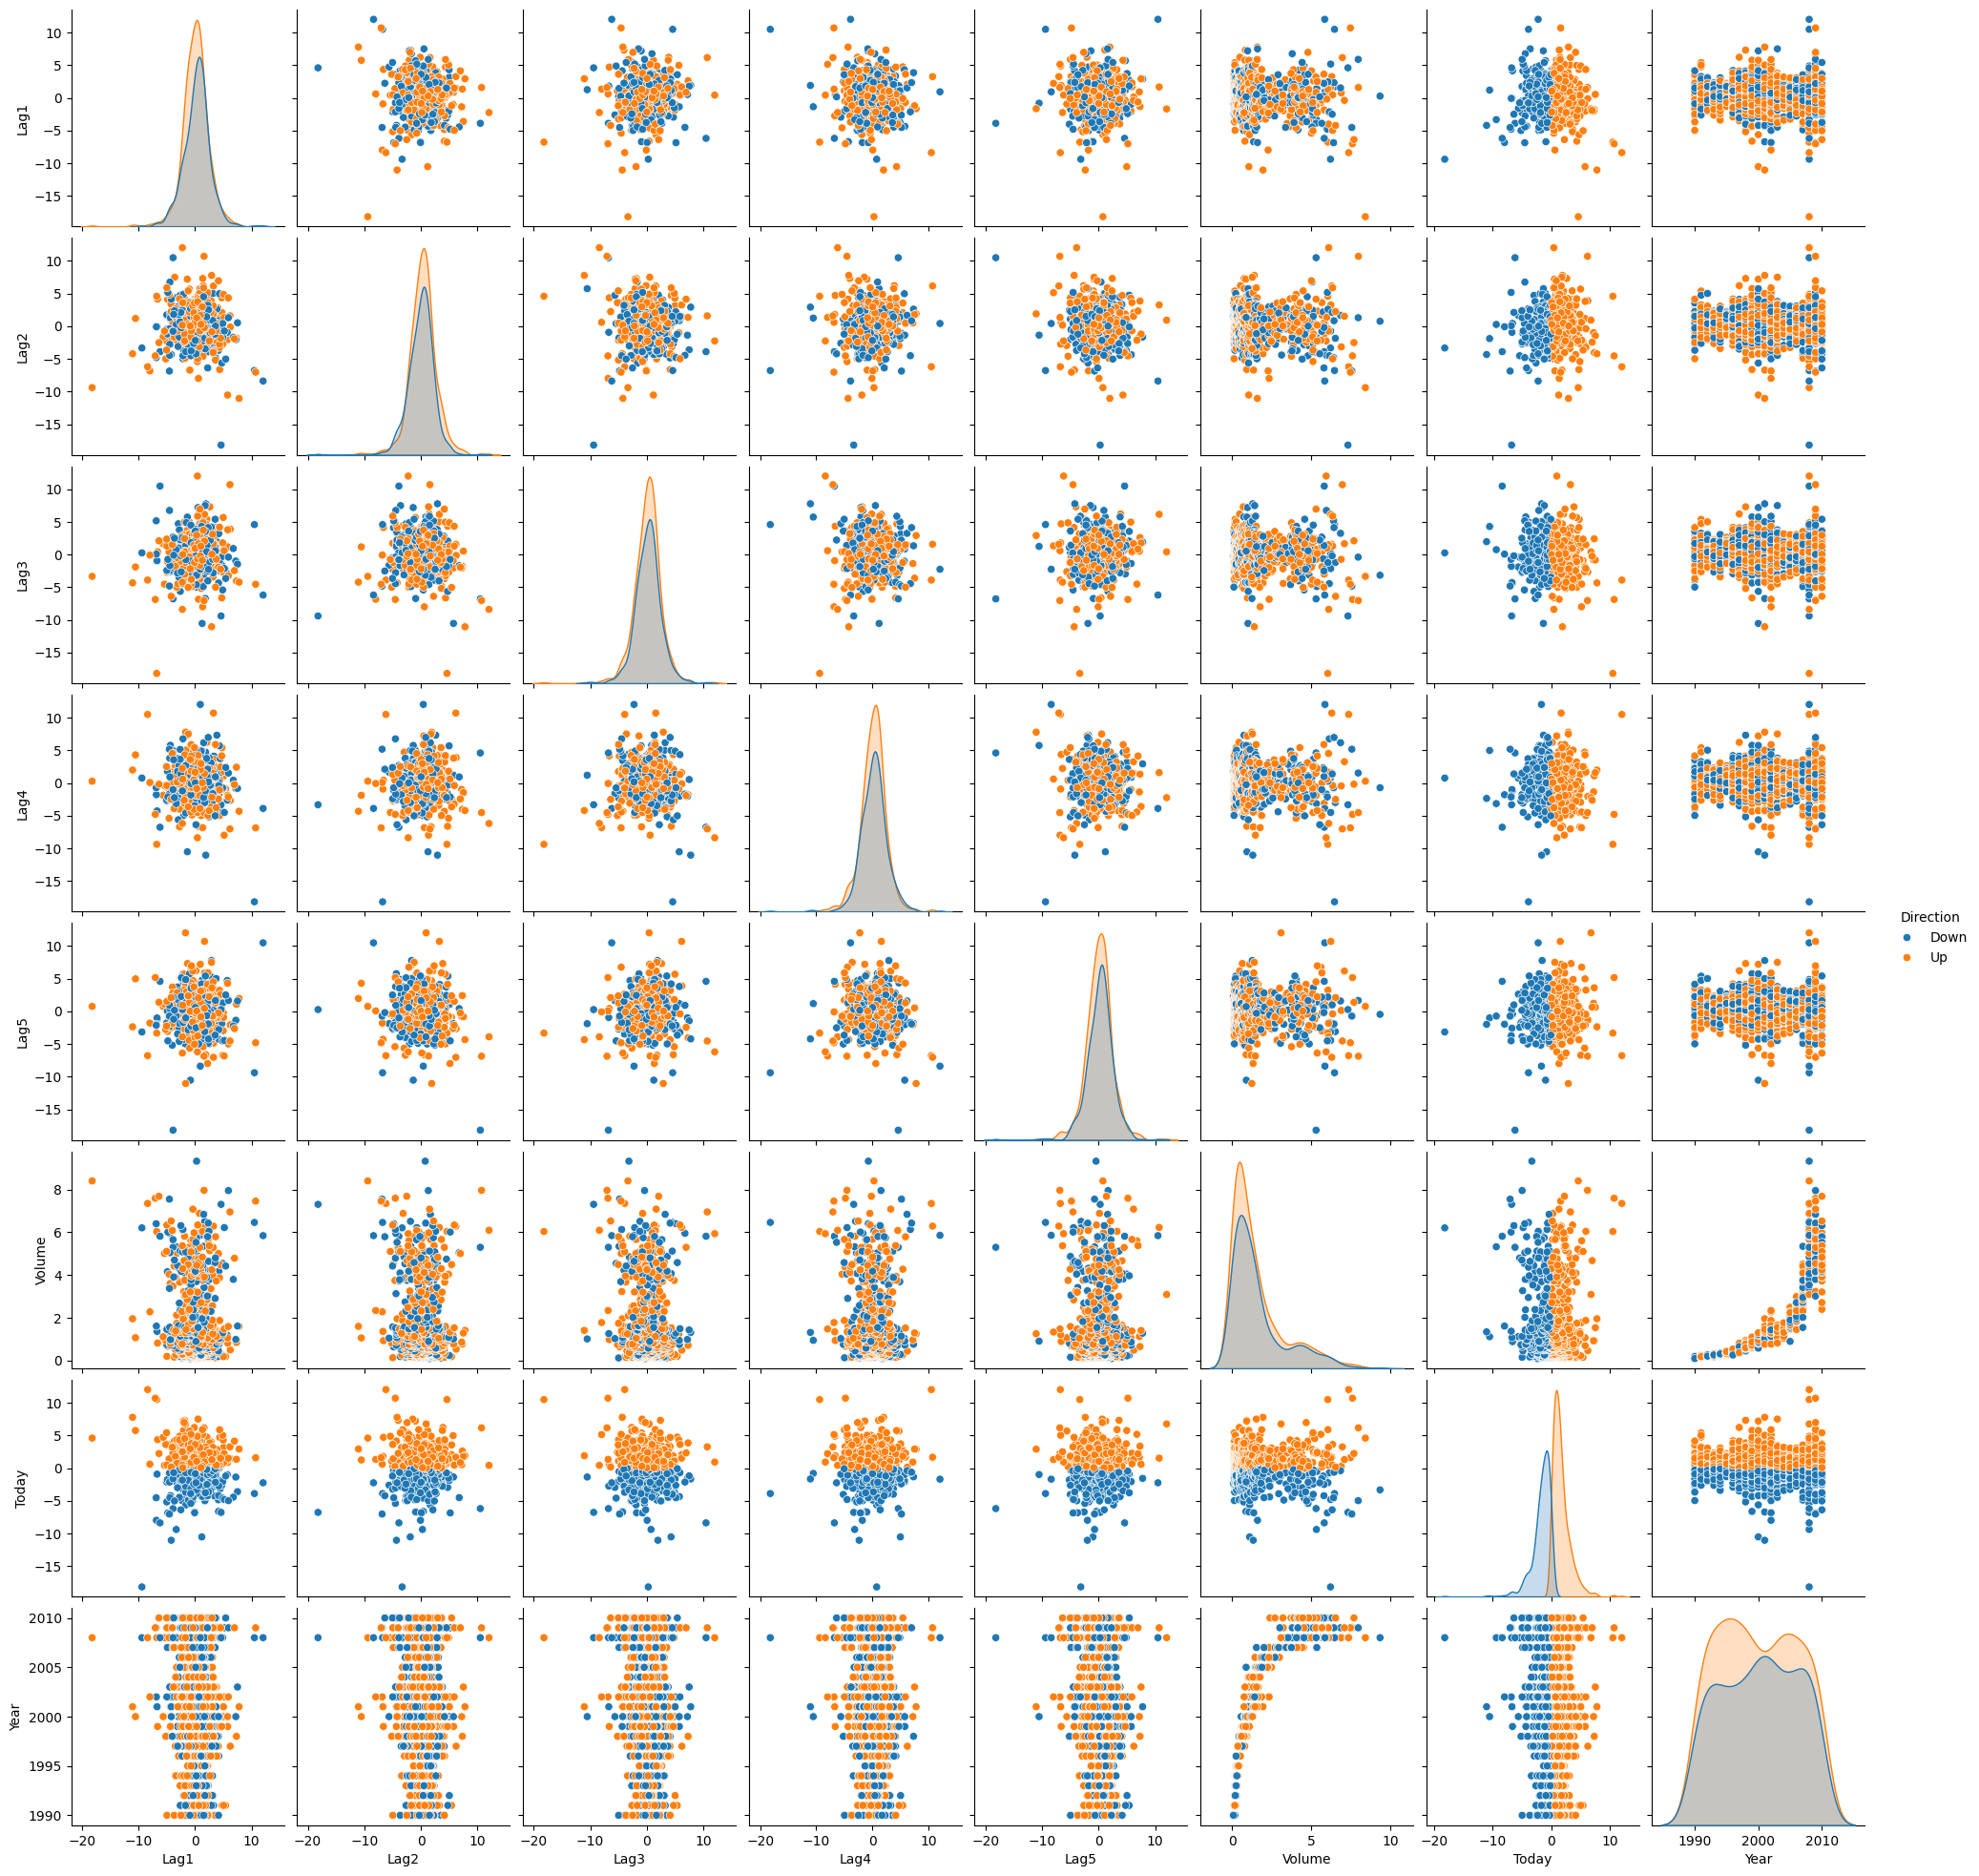

In [ ]:
sns.pairplot(weekly, vars=['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today','Year'], hue='Direction')
plt.show()

- Volume vs. Year:
There is a strong positive trend between Volume and Year, indicating that trading volume has increased steadily over time.

- Lag Variables vs. Today:
The scatterplots between Lag1–Lag5 and Today show no clear linear relationship. The points are widely scattered, suggesting that past weekly returns do not strongly predict this week’s return.

####(b) Use the full data set to perform a logistic regression with Direction as the response and the five lag variables plus Volume as predictors. Use the summary function to print the results. Do any of the predictors appear to be statistically significant? If so, which ones?

In [ ]:
X = weekly[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
y = (weekly['Direction'] == 'Up').astype(int)   # Convert to 1 (Up) / 0 (Down)

# Add a constant (intercept)
X = sm.add_constant(X)

# Fit the logistic regression model
logit_model = sm.Logit(y, X).fit()

# Print the summary
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Sat, 01 Nov 2025   Pseudo R-squ.:                0.006580
Time:                        03:13:10   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

- Only Lag2 has a p-value below 0.05, meaning it is statistically significant at the 5% level.  
- The positive coefficient for Lag2 suggests that a positive return two weeks ago increases the probability that the market will go up this week.  
- All other variables (Lag1, Lag3, Lag4, Lag5, Volume) do not appear significant.


####(c) Compute the confusion matrix and overall fraction of correct predictions. Explain what the confusion matrix is telling you about the types of mistakes made by logistic regression.

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

pred_prob = logit_model.predict(X)
pred_class = (pred_prob > 0.5).astype(int)
cm = confusion_matrix(y, pred_class)
acc = accuracy_score(y, pred_class)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Down", "Actual Up"],
    columns=["Predicted Down", "Predicted Up"]
)

print(cm_df)
print("\nAccuracy:", round(acc, 3))

             Predicted Down  Predicted Up
Actual Down              54           430
Actual Up                48           557

Accuracy: 0.561


- Using the fitted logistic regression model from (b),  we classify each week as Up if  $ \widehat{P}(\text{Up}) > 0.5 $,  and Down otherwise.

- $\text{Accuracy} = \frac{54 + 557}{54 + 430 + 48 + 557} = 0.561$. That is, the model correctly predicts the market direction 56.1% of the time.

- Logistic regression tends to predict Up most of the time.  It correctly classifies Up weeks more often than Down weeks.  
- Many Down weeks are incorrectly predicted as Up.  
- Overall, the model performs only slightly better than random guessing (≈50%).


####(d) Now fit the logistic regression model using a training data period from 1990 to 2008, with Lag2 as the only predictor. Compute the confusion matrix and the overall fraction of correct predictions for the held out data (that is, the data from 2009 and 2010).

In [ ]:
X_train = weekly[weekly['Year'] < 2009][['Lag2']]
y_train = (weekly[weekly['Year'] < 2009]['Direction'] == 'Up').astype(int)
X_test = weekly[weekly['Year'] >= 2009][['Lag2']]
y_test = (weekly[weekly['Year'] >= 2009]['Direction'] == 'Up').astype(int)

# Add constant (intercept)
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

# Fit logistic regression
logit_model2 = sm.Logit(y_train, X_train).fit()

# Predict on test set
pred_prob = logit_model2.predict(X_test)
pred_class = (pred_prob > 0.5).astype(int)

# Confusion matrix and accuracy
cm = confusion_matrix(y_test, pred_class)
acc = accuracy_score(y_test, pred_class)

# Display results
cm_df = pd.DataFrame(
    cm,
    index=["Actual Down", "Actual Up"],
    columns=["Predicted Down", "Predicted Up"]
)

print(cm_df)
print("\nAccuracy:", round(acc, 3))
print("\nModel Summary:\n")
print(logit_model2.summary())


Optimization terminated successfully.
         Current function value: 0.685555
         Iterations 4
             Predicted Down  Predicted Up
Actual Down               9            34
Actual Up                 5            56

Accuracy: 0.625

Model Summary:

                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                  985
Model:                          Logit   Df Residuals:                      983
Method:                           MLE   Df Model:                            1
Date:                Sat, 01 Nov 2025   Pseudo R-squ.:                0.003076
Time:                        03:43:44   Log-Likelihood:                -675.27
converged:                       True   LL-Null:                       -677.35
Covariance Type:            nonrobust   LLR p-value:                   0.04123
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------

- The model achieves better performance on the test data.  
- It correctly classifies most “Up” weeks but misses many “Down” weeks.  
- $\text{Accuracy} = \frac{9 + 56}{9 + 34 + 5 + 56} = 0.625
$. That is, the model correctly predicts the market direction 62.5% of the time.